<a href="https://colab.research.google.com/github/Akshatha7710/Face-Map/blob/main/FaceMap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install mediapipe==0.10.14 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 16.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.


In [11]:
import os, zipfile
from google.colab import files

uploaded = files.upload()
with zipfile.ZipFile(list(uploaded.keys())[0], 'r') as zip_ref:
    zip_ref.extractall("/content/images")

image_paths = []
for root, dirs, files_list in os.walk("/content/images"):
    if "__MACOSX" in root:
        continue
    for f in files_list:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('._'):
            image_paths.append(os.path.join(root, f))

image_paths.sort()
print(f"Found {len(image_paths)} images")

Saving Face Images.zip to Face Images.zip
Found 15 images


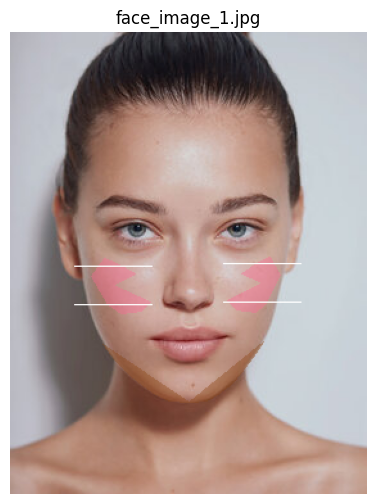

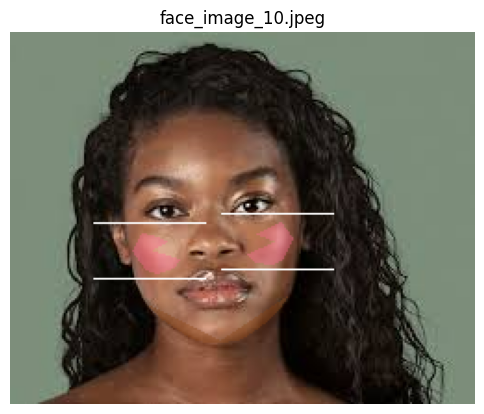

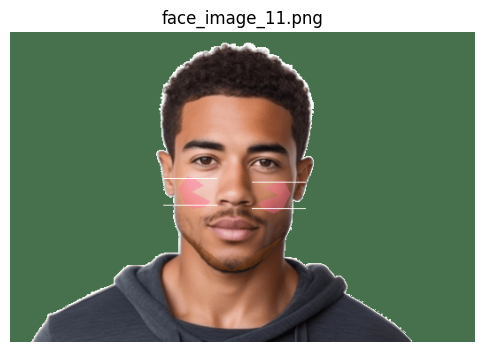

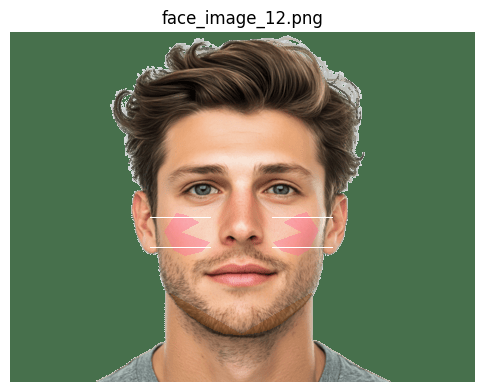

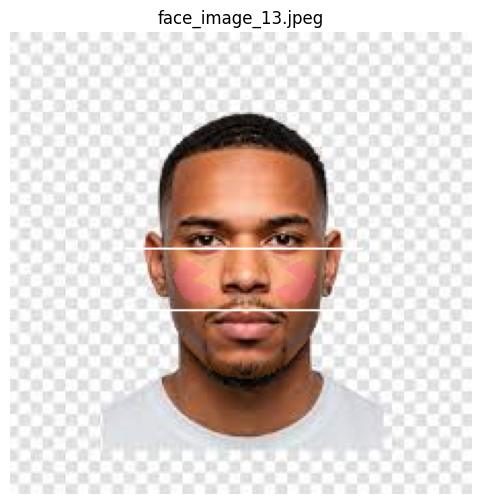

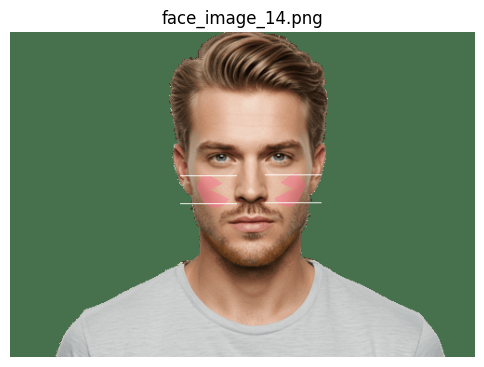

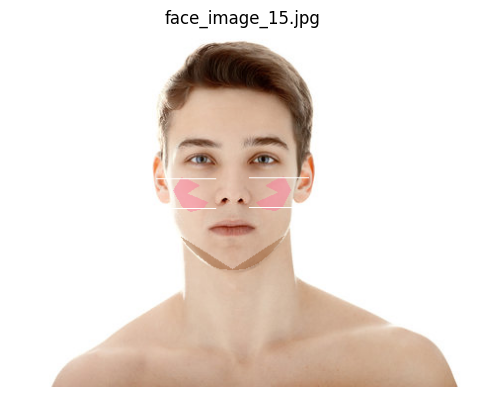

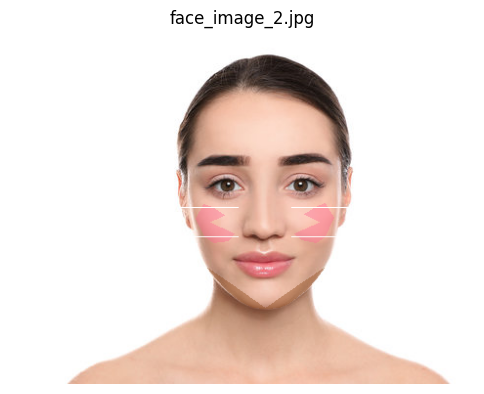

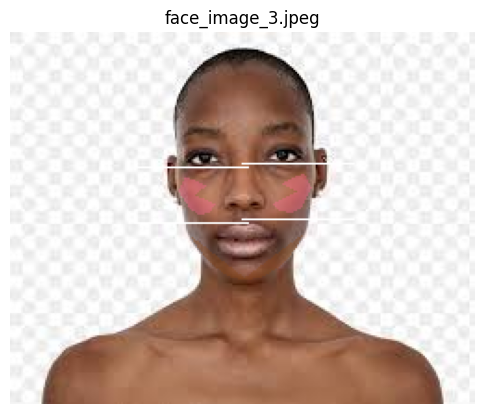

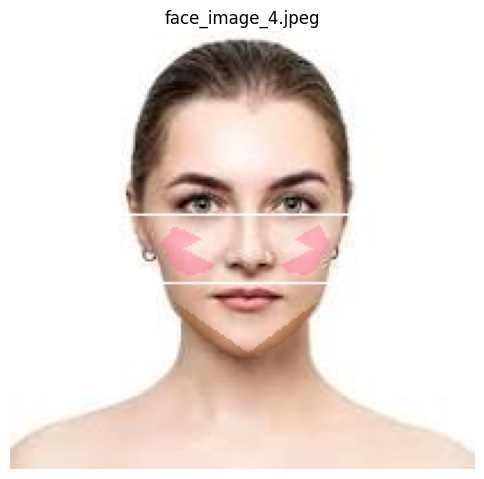

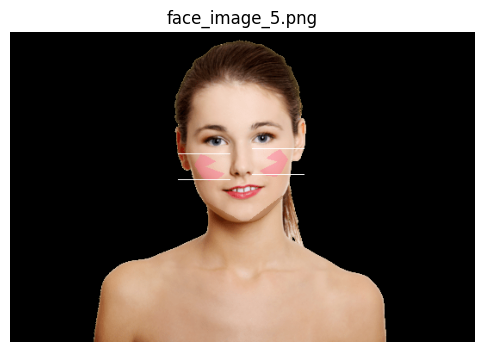

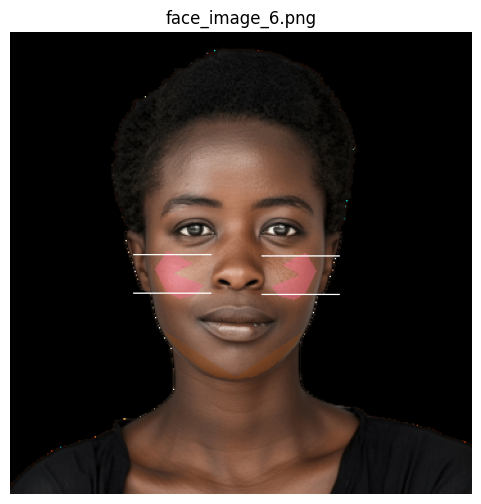

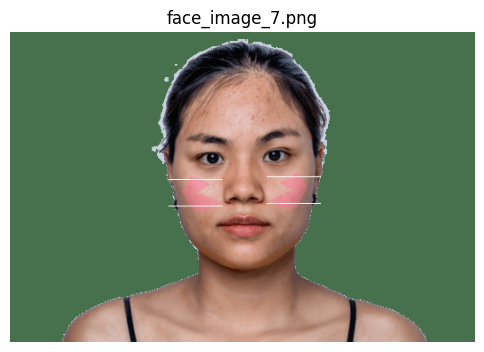

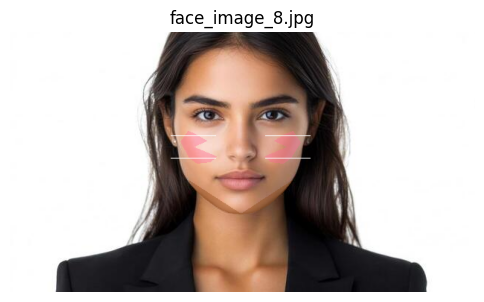

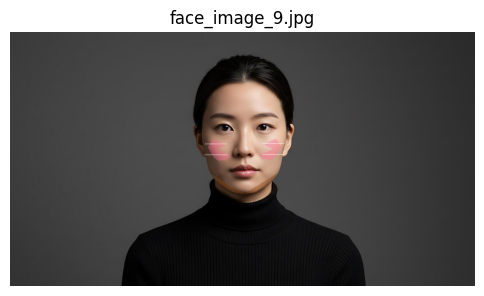

In [16]:
# ── Imports + setup ───────────────────────────────────────────────
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import os

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

# ── Makeup zone definitions ───────────────────────────────────────
ZONES = {
    "blush_left":     [50, 101, 118, 117, 123, 187, 207, 206, 203],
    "blush_right":    [280, 330, 347, 346, 352, 411, 427, 426, 423],
    "contour_left":   [172, 136, 150, 149, 176, 148, 152],
    "contour_right":  [397, 365, 379, 378, 400, 377, 152],
}

COLORS = {
    "blush_left":     (255, 105, 150, 80),
    "blush_right":    (255, 105, 150, 80),
    "contour_left":   (139, 69, 19, 90),
    "contour_right":  (139, 69, 19, 90),
}

# ── Drawing function ──────────────────────────────────────────────
def draw_makeup_zones(image, face_landmarks, h, w):
    overlay = image.copy()
    for zone_name, indices in ZONES.items():
        points = []
        for idx in indices:
            lm = face_landmarks[idx]
            points.append((int(lm.x * w), int(lm.y * h)))
        pts = np.array(points, dtype=np.int32)
        r, g, b, alpha = COLORS[zone_name]
        cv2.fillPoly(overlay, [pts], (b, g, r))
    cv2.addWeighted(overlay, 0.4, image, 0.6, 0, image)

    for zone_name in ["blush_left", "blush_right"]:
        indices = ZONES[zone_name]
        lm_center = face_landmarks[indices[0]]
        cx, cy = int(lm_center.x * w), int(lm_center.y * h)
        cv2.line(image, (cx - 30, cy - 15), (cx + 30, cy - 15), (255, 255, 255), 1)
        cv2.line(image, (cx - 30, cy + 15), (cx + 30, cy + 15), (255, 255, 255), 1)
    return image

# ── Run on all images ─────────────────────────────────────────────
options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='face_landmarker.task'),
    running_mode=VisionRunningMode.IMAGE
)

with FaceLandmarker.create_from_options(options) as landmarker:
    for image_path in image_paths:
        image = cv2.imread(image_path)
        if image is None:
            continue

        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)
        result = landmarker.detect(mp_image)

        if result.face_landmarks:
            h, w, _ = image.shape
            annotated = draw_makeup_zones(image.copy(), result.face_landmarks[0], h, w)
            plt.figure(figsize=(6, 6))
            plt.title(os.path.basename(image_path))
            plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.show()
        else:
            print(f"No face detected: {os.path.basename(image_path)}")